# 03 — The GSS vs. purpose-built surveys of American Jews

Notebook 02 showed the GSS Jewish subsample is tiny (a few dozen per round)
and its yearly estimates are noisy. Here we ask: **do the GSS trends agree
with the sources actually designed to measure the Jewish population?**

External estimates compiled from published reports (shares of **U.S. adults**):

| definition | sources |
|---|---|
| **Jewish by religion** | NSRI 1990, ARIS 2001/2008, NJPS 1990/2000-01, Pew Religious Landscape Studies 2007/2014/2023-24, Pew Jewish Americans 2013/2020, Brandeis AJPP |
| **Net Jewish** (by religion + Jews of no religion) | Pew 2013, Pew 2020, AJPP |

Citations: [Pew 2013](https://www.pewresearch.org/religion/2013/10/01/a-portrait-of-jewish-americans/),
[Pew 2020](https://www.pewresearch.org/religion/2021/05/11/jewish-americans-in-2020/),
[Pew population-size chapter](https://www.pewresearch.org/religion/2021/05/11/the-size-of-the-u-s-jewish-population/),
[Pew RLS 2023-24](https://www.pewresearch.org/religion/2025/02/26/decline-of-christianity-in-the-us-has-slowed-may-have-leveled-off/),
[ARIS 2008](https://www.americanreligionsurvey-aris.org/catholics-on-the-move-non-religious-on-the-rise/),
[AJPP](https://ajpp.brandeis.edu/), [NJPS via Berman Jewish DataBank](https://www.jewishdatabank.org/).

The two definitions map onto the two GSS series from notebook 02:
GSS *Jewish by religion* ↔ external *by religion*; GSS *Jewish by religion
or upbringing* is the GSS's (imperfect) analogue of *net Jewish*.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

DATA = os.path.abspath(os.path.join('..', 'data'))
summary = pd.read_parquet(os.path.join(DATA, 'derived', 'gss_jewish_yearly_summary.parquet'))
jbr = summary.loc['jewish_by_religion']
jbru = summary.loc['jewish_relig_or_raised']

In [2]:
# Published estimates: % of US adults. `x` = approximate fielding midpoint.
# n_jewish marked approximate (~) where derived as share x total sample.
ext = pd.DataFrame([
    # source family,        x,     share, definition,    n_jewish, note
    ('NSRI/ARIS',        1990.0,   1.8, 'by religion',  '~2,000',  '113,723 adults screened, RDD'),
    ('NSRI/ARIS',        2001.0,   1.3, 'by religion',  '~1,000',  '50,281 adults, open-ended religion Q'),
    ('NSRI/ARIS',        2008.0,   1.2, 'by religion',  '~650',    '54,461 adults, open-ended religion Q'),
    ('NJPS',             1990.5,   1.8, 'by religion',  '2,441',   'dedicated Jewish population survey'),
    ('NJPS',             2000.5,   1.8, 'by religion',  '4,523',   'dedicated survey; disputed methodology'),
    ('Pew RLS',          2007.0,   1.7, 'by religion',  '~600',    '~35,000 adults per wave'),
    ('Pew RLS',          2014.0,   1.9, 'by religion',  '~670',    '~35,000 adults per wave'),
    ('Pew RLS',          2023.5,   1.7, 'by religion',  '~620',    '~36,900 adults'),
    ('Pew Jewish survey', 2013.0,  1.8, 'by religion',  '3,475 net', 'dedicated survey, RDD'),
    ('Pew Jewish survey', 2020.0,  1.7, 'by religion',  '3,836',   'dedicated survey, ABS panel'),
    ('AJPP (Brandeis)',  2020.0,   1.9, 'by religion',  'synthesis', 'Bayesian synthesis, 1.4M+ respondents'),
    ('Pew Jewish survey', 2013.0,  2.2, 'net Jewish',   '3,475',   'incl. 0.5pp Jews of no religion'),
    ('Pew Jewish survey', 2020.0,  2.4, 'net Jewish',   '4,718',   'incl. 0.6pp Jews of no religion'),
    ('AJPP (Brandeis)',  2020.0,   2.4, 'net Jewish',   'synthesis', '6.1M adults; 7.6M total incl. children'),
], columns=['source', 'x', 'share', 'definition', 'n_jewish', 'note'])
ext

,source,x,share,definition,n_jewish,note
0,NSRI/ARIS,1990.0,1.8,by religion,"~2,000","113,723 adults screened, RDD"
1,NSRI/ARIS,2001.0,1.3,by religion,"~1,000","50,281 adults, open-ended religion Q"
2,NSRI/ARIS,2008.0,1.2,by religion,~650,"54,461 adults, open-ended religion Q"
3,NJPS,1990.5,1.8,by religion,"2,441",dedicated Jewish population survey
4,NJPS,2000.5,1.8,by religion,"4,523",dedicated survey; disputed methodology
5,Pew RLS,2007.0,1.7,by religion,~600,"~35,000 adults per wave"
6,Pew RLS,2014.0,1.9,by religion,~670,"~35,000 adults per wave"
7,Pew RLS,2023.5,1.7,by religion,~620,"~36,900 adults"
8,Pew Jewish survey,2013.0,1.8,by religion,"3,475 net","dedicated survey, RDD"
9,Pew Jewish survey,2020.0,1.7,by religion,"3,836","dedicated survey, ABS panel"


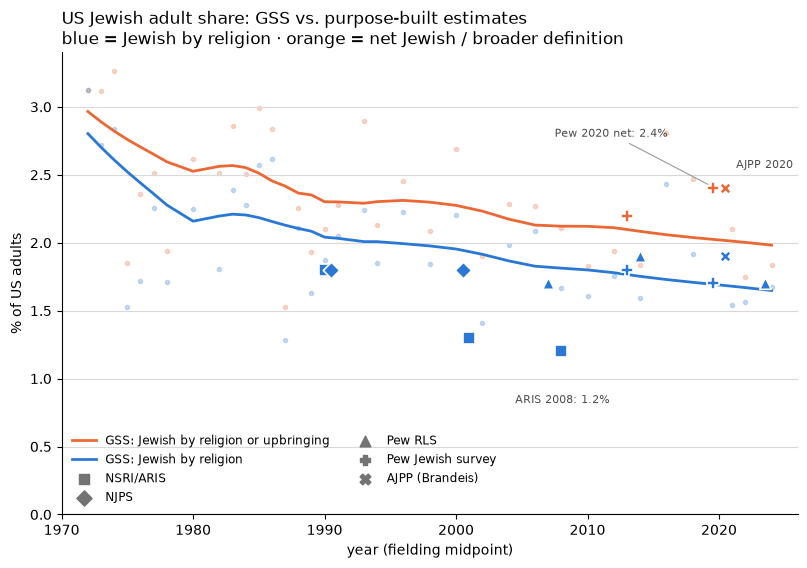

In [3]:
PALETTE = {'by religion': '#2a78d6', 'net Jewish': '#eb6834'}  # validated slots 1-2
MARKERS = {'NSRI/ARIS': 's', 'NJPS': 'D', 'Pew RLS': '^',
           'Pew Jewish survey': 'P', 'AJPP (Brandeis)': 'X'}
GRID = dict(color='0.85', linewidth=0.8)

fig, ax = plt.subplots(figsize=(9.5, 6))

# GSS backdrop: yearly points (faint) + lowess trend, from notebook 02
for res, key, label in [(jbru, 'net Jewish', 'GSS: Jewish by religion or upbringing'),
                        (jbr, 'by religion', 'GSS: Jewish by religion')]:
    c = PALETTE[key]
    ax.plot(res.index, 100 * res.share, 'o', ms=3, color=c, alpha=0.25, zorder=1)
    s = lowess(res.share, res.index.to_numpy(), frac=0.4)
    ax.plot(s[:, 0], 100 * s[:, 1], color=c, lw=2, label=label, zorder=2)

# external estimates: marker shape = source family, color = definition
dodge = {('Pew Jewish survey', 2020.0): -0.45, ('AJPP (Brandeis)', 2020.0): +0.45}
for (src, marker) in MARKERS.items():
    rows = ext[ext.source == src]
    for _, r in rows.iterrows():
        dx = dodge.get((src, r.x), 0.0)
        ax.scatter(r.x + dx, r.share, marker=marker, s=70,
                   color=PALETTE[r.definition], edgecolor='white',
                   linewidth=1.2, zorder=4)
    # one legend entry per source family, in neutral gray
    ax.scatter([], [], marker=marker, s=60, color='0.45', label=src)

ax.set_ylim(0, 3.4)
ax.set_xlim(1970, 2026)
ax.set_ylabel('% of US adults')
ax.set_xlabel('year (fielding midpoint)')
ax.set_title('US Jewish adult share: GSS vs. purpose-built estimates\n'
             'blue = Jewish by religion · orange = net Jewish / broader definition',
             loc='left')
ax.legend(frameon=False, loc='lower left', fontsize=8.5, ncol=2)
ax.grid(axis='y', **GRID)
ax.spines[['top', 'right']].set_visible(False)

# selective direct labels for points a reader will ask about
ax.annotate('ARIS 2008: 1.2%', (2008, 1.2), xytext=(2004.5, 0.82),
            fontsize=8, color='0.3')
ax.annotate('Pew 2020 net: 2.4%', (2019.35, 2.42), xytext=(2007.5, 2.78),
            fontsize=8, color='0.3',
            arrowprops=dict(arrowstyle='-', color='0.6', lw=0.8))
ax.annotate('AJPP 2020', (2020.45, 2.4), xytext=(2021.3, 2.55),
            fontsize=8, color='0.3')
plt.show()

**Reading the overlay:**

- **The GSS trend is in the right place.** Its lowess line for *Jewish by
  religion* runs ~2.2% (1980s) to ~1.7% (2020s), passing within a whisker of
  NSRI 1990 (1.8%), NJPS 1990/2000 (1.8%), the three Religious Landscape
  Studies (1.7–1.9%), and Pew 2020 (1.7%). For a free byproduct of an
  omnibus survey, that is remarkable agreement.
- **ARIS 2001/2008 sit below everything** — 1.3% and 1.2%, versus 1.7–1.9%
  from every other source in the same era, GSS included. Its open-ended
  "What is your religion, if any?" wording pushed marginal identifiers to
  "none". Question wording moves the answer as much as sampling error.
- **The definitional gap is visible as the blue–orange split.** Pew's net
  Jewish (2.2–2.4%) exceeds its own by-religion figure by ~0.6pp — the Jews
  of no religion. The GSS broader definition lands in the same band
  (~1.9–2.3%), but only by luck of offsetting flaws: it misses never-raised-
  Jewish identifiers and includes raised-Jewish non-identifiers.
- **A single GSS year cannot adjudicate any of this.** Its ±1pp confidence
  interval is wider than the entire spread between sources (1.2%–2.4%).
  The GSS earns its place through the 50-year trend, not the level.

## Sample sizes: the GSS vs. everyone else


In [4]:
sizes = pd.DataFrame([
    ('GSS (per round)', '1972-2024', '1,400-4,500', '21-78',
     'omnibus survey; religion questions only'),
    ('GSS (pooled, all rounds)', '1972-2024', '75,699', '1,468',
     'sum over 34 rounds'),
    ('NSRI', '1990', '113,723', '~2,000', 'RDD phone screening'),
    ('ARIS', '2001', '50,281', '~1,000', 'open-ended religion question'),
    ('ARIS', '2008', '54,461', '~650', 'open-ended religion question'),
    ('NJPS', '1990', '~125,000 screened', '2,441', 'dedicated Jewish survey'),
    ('NJPS', '2000-01', '~175,000 screened', '4,523', 'dedicated; disputed methods'),
    ('Pew RLS', '2007 / 2014 / 2023-24', '~35,000 per wave', '~600-850',
     'religion-focused omnibus'),
    ('Pew Jewish Americans', '2013', '~70,000 screened', '3,475', 'RDD'),
    ('Pew Jewish Americans', '2020', '~68,000 screened', '4,718',
     '3,836 by religion + 882 no religion'),
    ('AJPP (Brandeis)', 'rolling', '1.4M+ pooled', 'synthesis',
     'Bayesian model over hundreds of surveys'),
], columns=['source', 'years', 'total sample', 'Jewish respondents', 'design'])
sizes.set_index('source')

,years,total sample,Jewish respondents,design
source,,,,
GSS (per round),1972-2024,"1,400-4,500",21-78,omnibus survey; religion questions only
"GSS (pooled, all rounds)",1972-2024,"75,699","1,468",sum over 34 rounds
NSRI,1990,"113,723","~2,000",RDD phone screening
ARIS,2001,"50,281","~1,000",open-ended religion question
ARIS,2008,"54,461",~650,open-ended religion question
NJPS,1990,"~125,000 screened","2,441",dedicated Jewish survey
NJPS,2000-01,"~175,000 screened","4,523",dedicated; disputed methods
Pew RLS,2007 / 2014 / 2023-24,"~35,000 per wave",~600-850,religion-focused omnibus
Pew Jewish Americans,2013,"~70,000 screened","3,475",RDD


In [5]:
# cross-check the pooled-GSS Jewish count quoted above
df = pd.read_parquet(os.path.join(DATA, 'derived', 'gss_jewish_identity.parquet'))
print('GSS 1972-2024 pooled: respondents =', len(df),
      '| Jewish by religion =', int((df.relig == 'jewish').sum()),
      '| raised Jewish =', int((df.relig16 == 'jewish').sum()))

GSS 1972-2024 pooled: respondents = 75699 | Jewish by religion = 1468 | raised Jewish = 1455


**The punchline:** one Pew Jewish Americans survey (4,718 Jewish
respondents) contains **three times as many Jewish respondents as all 34 GSS
rounds combined** (~1,500). AJPP gets around the same constraint not with one
big survey but by pooling everyone else's. The GSS's unique asset is the
thing no purpose-built survey has: an unbroken, identically-worded question
series running back to 1972.

| use case | best source |
|---|---|
| national demographic structure of US Jews | Pew Jewish Americans 2020 |
| by-religion vs no-religion split | Pew 2013 / 2020 (designed for it) |
| state / county / metro estimates | AJPP |
| 50-year trend, comparison with other groups | pooled GSS |
| a specific metro area | local federation study (Berman DataBank) |
